In [1]:
!pip install scikit-learn pandas matplotlib seaborn joblib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Loaded Successfully ✅")
print("Shape:", X.shape)

Dataset Loaded Successfully ✅
Shape: (569, 30)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (455, 30)
Test Shape: (114, 30)


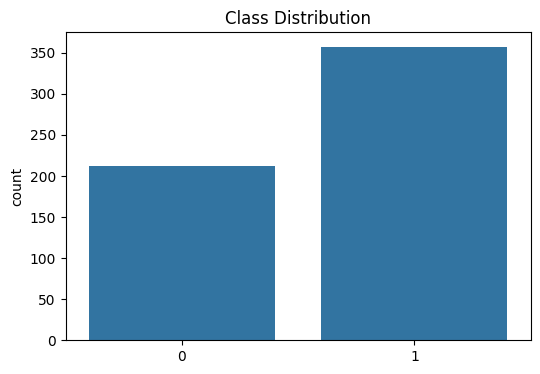

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

In [6]:
models = {

    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {"model__C":[0.1,1,10]}
    },

    "Random Forest": {
        "model": RandomForestClassifier(),
        "params":{
            "model__n_estimators":[100,200],
            "model__max_depth":[None,10]
        }
    },

    "SVM": {
        "model": SVC(),
        "params":{
            "model__C":[0.1,1],
            "model__kernel":["linear","rbf"]
        }
    },

    "KNN": {
        "model": KNeighborsClassifier(),
        "params":{
            "model__n_neighbors":[3,5,7]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params":{
            "model__max_depth":[None,5,10]
        }
    }
}

In [14]:
scores = {}
best_model = None
best_score = 0
best_pipeline = None

print("🚀 Training Models...\n")

for name, config in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_select", SelectKBest(score_func=f_classif, k=10)),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        pipeline,
        config["params"],
        cv=5,
        scoring="accuracy"
    )

    grid.fit(X_train, y_train)

    test_score = grid.score(X_test, y_test)
    scores[name] = test_score

    print(f"{name}")
    print("Accuracy:", round(test_score,4))
    print("Best Params:", grid.best_params_)
    print("------------------")

    if test_score > best_score:
        best_score = test_score
        best_model = name
        best_pipeline = grid.best_estimator_

🚀 Training Models...

Logistic Regression
Accuracy: 0.9825
Best Params: {'model__C': 10}
------------------
Random Forest
Accuracy: 0.9561
Best Params: {'model__max_depth': None, 'model__n_estimators': 200}
------------------
SVM
Accuracy: 0.9825
Best Params: {'model__C': 1, 'model__kernel': 'linear'}
------------------
KNN
Accuracy: 0.9737
Best Params: {'model__n_neighbors': 3}
------------------
Decision Tree
Accuracy: 0.9298
Best Params: {'model__max_depth': 5}
------------------


In [15]:
print("\n🏆 Best Model:", best_model)
print("🏆 Best Accuracy:", round(best_score,4))


🏆 Best Model: Logistic Regression
🏆 Best Accuracy: 0.9825


In [16]:
joblib.dump(best_pipeline, "best_model.pkl")
print("✅ Model saved as best_model.pkl")

✅ Model saved as best_model.pkl


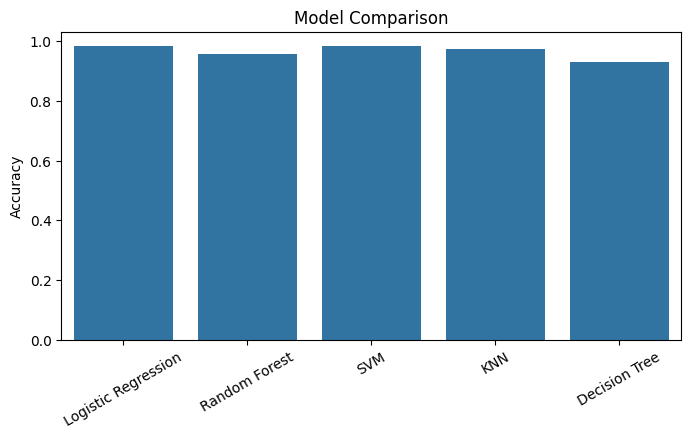

In [17]:
plt.figure(figsize=(8,4))
sns.barplot(x=list(scores.keys()), y=list(scores.values()))
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [20]:
import joblib

# Load saved model
loaded_model = joblib.load("best_model.pkl")

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [22]:
# Take sample input
sample = X_test.iloc[0:1]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)
print("Actual:", y_test[0])

Prediction: [1]
Actual: 1


In [23]:
def predict_new(input_data):
    model = joblib.load("best_model.pkl")
    return model.predict(input_data)

In [24]:
# Example custom input
new_sample = X_test.iloc[1:2]

result = predict_new(new_sample)
print("Custom Prediction:", result)

Custom Prediction: [0]
